# Acoustic Uroflowmetry Prototype
Estimate urinary flow rate from sound using DSP features and super vised ML models to estimate new measures.

Pipeline:
1. Calibration from known flows
2. Feature extraction (MFCC + spectral features) with Digital Signal Processing
3. RMS-based segmentation
4. KNN similarity to estimate flow per segment
5. Plot uroflow curve


In [96]:
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

import operator

from sklearn.neighbors import NearestNeighbors
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# from sklearn.ensemble import RandomForestClassifier

import glob
import os

from scipy.signal import butter, lfilter




## Feature Extraction

In [97]:
def extract_features(y, sr):

    # -------------------------
    # 0️⃣ Pré-traitement robuste micro
    # -------------------------
    
    # Enlève les très basses fréquences (bruits de pièce)
    # y = librosa.effects.preemphasis(y)

    # =========================
    # 1️⃣ MFCC (texture globale)
    # =========================
    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=13,
        n_fft=2048,
        hop_length=512
    )

    # Normalisation cepstrale (CMVN) : stabilise les MFCC entre micros
    # mfcc = (mfcc - np.mean(mfcc, axis=1, keepdims=True)) / \
    #        (np.std(mfcc, axis=1, keepdims=True) + 1e-8)

    # mfcc = mfcc - np.mean(mfcc, axis=1, keepdims=True)

    features = []
    features.extend(np.mean(mfcc, axis=1))
    features.extend(np.std(mfcc, axis=1))

    # =========================
    # 2️⃣ Features spectrales
    # =========================
    spec_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    features.append(np.mean(spec_centroid))
    features.append(np.std(spec_centroid))

    spec_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    features.append(np.mean(spec_bandwidth))
    features.append(np.std(spec_bandwidth))

    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, roll_percent=0.85)
    features.append(np.mean(rolloff))
    features.append(np.std(rolloff))

    # =========================
    # 3️⃣ Bruit vs tonal
    # =========================
    spec_flatness = librosa.feature.spectral_flatness(y=y)
    features.append(np.mean(spec_flatness))
    features.append(np.std(spec_flatness))

    # =========================
    # 4️⃣ Dynamique / énergie
    # =========================
    rms = librosa.feature.rms(y=y)
    features.append(np.mean(rms))
    features.append(np.std(rms))

    # =========================
    # 5️⃣ Rugosité temporelle
    # =========================
    zcr = librosa.feature.zero_crossing_rate(y)
    features.append(np.mean(zcr))
    features.append(np.std(zcr))

    # =========================
    # 6️⃣ Flux spectral (variation du spectre dans le temps)
    # Très corrélé aux turbulences et donc au débit
    # Plus le flux est élevé, plus le jet est turbulent / intense
    # =========================
    # Calcul du spectrogramme magnitude
    S = np.abs(librosa.stft(y, n_fft=2048, hop_length=512))
    # Flux spectral : différence entre frames successives
    flux = np.sqrt(np.sum(np.diff(S, axis=1)**2, axis=0)) / S.shape[0]
    features.append(np.mean(flux))
    features.append(np.std(flux))

    return np.array(features)


In [98]:
def preprocess_audio(
    file,                     # chemin du fichier audio
    sr=32000,                 # fréquence cible après resampling
    lowcut=150,               # fréquence minimale utile pour le flux liquide
    highcut=8000,             # fréquence maximale utile
    filter_order=4,           # ordre du filtre passe-bande
    target_rms=0.1,           # niveau RMS cible (stabilise les micros)
    compression_strength=0.7, # compression dynamique (réduit écarts entre appareils)
    trim_signal=False,         # active ou non la suppression du silence début/fin
    trim_padding=1.0,         # durée conservée avant/après le flux détecté (secondes)
    max_internal_silence=2.0  # silence max autorisé au milieu d'un flux (secondes)
):
    """
    Prétraitement complet pour analyse acoustique du débit urinaire.
    """

    # ---------------------------------------------------------
    # 1) Chargement + mono + resampling
    # ---------------------------------------------------------
    y, sr = librosa.load(file, sr=sr, mono=True)

    # ---------------------------------------------------------
    # 2) Réduction du bruit ambiant (spectral gating)
    # ---------------------------------------------------------
    stft = librosa.stft(y)
    magnitude, phase = librosa.magphase(stft)

    noise_profile = np.mean(magnitude[:, :20], axis=1, keepdims=True)
    reduction_factor = 1.5
    cleaned_mag = np.maximum(magnitude - reduction_factor * noise_profile, 0)

    y = librosa.istft(cleaned_mag * phase)

    # ---------------------------------------------------------
    # 3) Suppression silence début / fin (optionnelle)
    # avec gestion des pauses internes
    # ---------------------------------------------------------
    if trim_signal:

        rms = librosa.feature.rms(y=y)[0]
        threshold = np.percentile(rms, 65)

        frame_length = int(len(y) / len(rms))
        frame_time = frame_length / sr

        active = rms > threshold
        active_idx = np.where(active)[0]

        if len(active_idx) > 0:

            segments = []
            start = active_idx[0]

            for i in range(1, len(active_idx)):
                gap = active_idx[i] - active_idx[i-1]

                silence_duration = gap * frame_time

                if silence_duration > max_internal_silence:
                    segments.append((start, active_idx[i-1]))
                    start = active_idx[i]

            segments.append((start, active_idx[-1]))

            global_start = segments[0][0]
            global_end = segments[-1][1]

            start_sample = max(0, int(global_start * frame_length - trim_padding * sr))
            end_sample = min(len(y), int(global_end * frame_length + trim_padding * sr))

            y = y[start_sample:end_sample]

    # ---------------------------------------------------------
    # 4) Suppression offset DC
    # ---------------------------------------------------------
    y = y - np.mean(y)

    # ---------------------------------------------------------
    # 5) Normalisation RMS
    # ---------------------------------------------------------
    rms = np.sqrt(np.mean(y**2) + 1e-9)
    y = y * (target_rms / rms)

    # ---------------------------------------------------------
    # 6) Filtre turbulence liquide
    # ---------------------------------------------------------
    nyq = 0.5 * sr
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(filter_order, [low, high], btype="band")
    y = lfilter(b, a, y)

    # ---------------------------------------------------------
    # 7) Compression dynamique
    # ---------------------------------------------------------
    y = np.sign(y) * (np.abs(y) ** compression_strength)

    # ---------------------------------------------------------
    # 8) Normalisation finale: suppression de l'information lié au materiel
    # ---------------------------------------------------------

    '''suppression essentiellement :

            volume global du micro
            distance au micro
            gain automatique
            différences de niveau entre appareils
    '''
    y = librosa.util.normalize(y)

    return y, sr


## Build Dataset of extracted features (Calibration or Test)

In [ ]:
def build_dataset(folder='calibration_sounds_features', margin_sec=3):
    rows = []

    feature_names = [
        "mfcc1_mean","mfcc2_mean","mfcc3_mean","mfcc4_mean","mfcc5_mean",
        "mfcc6_mean","mfcc7_mean","mfcc8_mean","mfcc9_mean","mfcc10_mean",
        "mfcc11_mean","mfcc12_mean","mfcc13_mean",

        "mfcc1_std","mfcc2_std","mfcc3_std","mfcc4_std","mfcc5_std",
        "mfcc6_std","mfcc7_std","mfcc8_std","mfcc9_std","mfcc10_std",
        "mfcc11_std","mfcc12_std","mfcc13_std",

        "spec_centroid_mean","spec_centroid_std",
        "spec_band_mean","spec_band_std",
        "spec_rolloff_mean","spec_rolloff_std",
        "spec_flat_mean","spec_flat_std",
        "rms_mean","rms_std",
        "zero_cross_rate_mean","zero_cross_rate_std",
        "flux_mean","flux_std",
        "debit"
    ]

    files = glob.glob(os.path.join(folder, "*.wav"))

    files_sorted = sorted(
        files,
        key=lambda x: float(os.path.basename(x).split("_")[0])
    )

    for file in files_sorted:

        debit = float(os.path.basename(file).partition('_')[0])

        # y, sr = librosa.load(file, sr=32000)
        # Normalisation du son avant extraction des features
        y, sr = preprocess_audio(file, sr=32000, trim_signal=False, trim_padding=margin_sec)


        feat = extract_features(y, sr)
        rows.append(np.append(feat, debit))

    df = pd.DataFrame(rows,columns=feature_names)
    df.to_csv(folder + "_features.csv", index=False)
    print(f'Dataset saved as {folder}_features.csv')



# Build Calibration Dataset 

In [100]:

build_dataset('sons_tests')

df_test=pd.read_csv("sons_tests_features.csv", sep=",")

Dataset saved as sons_tests_features.csv


In [101]:
build_dataset('calibration_sounds')

df=pd.read_csv("calibration_sounds_features.csv", sep=",")

Dataset saved as calibration_sounds_features.csv


# Features Analysis

In [102]:
import pandas as pd
import plotly.express as px

# Charger les données
df = pd.read_csv("calibration_sounds_features.csv", sep=",")

# Bornes des plages
bins = [0, 4, 8, 12, 16, 20]
labels = ["0-4mls", "4-8mls", "8-12mls", "12-16mls", "16-20mls"]

# Variable catégorielle
df["debit_range"] = pd.cut(
    df["debit"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Scatter interactif
fig = px.scatter(
    df,
    # x="mfcc7_mean",
    # y="rms_mean",
    x="mfcc12_mean",
    y="mfcc9_mean",
    color="debit_range",
    hover_data={
        "debit": True,
        "mfcc12_mean": True,
        "mfcc9_mean": True
    },
    title="Scatter plot MFCC12 vs MFCC9 par plage de débit"
)

fig.show()


In [103]:
df[["mfcc7_mean","spec_rolloff_mean", "debit"]].corr()

,mfcc7_mean,spec_rolloff_mean,debit
mfcc7_mean,1.000000,-0.115632,-0.222035
spec_rolloff_mean,-0.115632,1.000000,-0.489880
debit,-0.222035,-0.489880,1.000000


## Load Calibration and Prepare KNN

Préparation jeux de données

In [104]:
calib = pd.read_csv("calibration_sounds_features.csv", sep=",")
# X = features
X = calib.iloc[:, :-1]
# y = débit (target)
y = calib.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

jeu_test_real = pd.read_csv("sons_tests_features.csv", sep=",")

X_real = jeu_test_real.iloc[:, :-1]
y_real = jeu_test_real.iloc[:, -1]


Instenciation des modèles de ML pour benchmark

In [105]:
# model KNN regressor
from xml.parsers.expat import model
    
# Modèle supervisé
model_KNN = KNeighborsRegressor(
        n_neighbors=3,
        metric='euclidean',
        weights='distance'   # ou'uniform', 'distance' si tu veux pondérer par proximité
    )
    
train_KNN = KNeighborsRegressor(
        n_neighbors=3,
        metric='euclidean',
        weights='distance'
    )
model_KNN.fit(X, y) # entrainemet du modèle sur tout le dataset de calibration pour certaines analyses
train_KNN.fit(X_train, y_train)

# Random Forest
from sklearn.ensemble import RandomForestRegressor

    # entrainement tout le set de données
model_rf = RandomForestRegressor(random_state=42)
train_rf = RandomForestRegressor(random_state=42)

model_rf.fit(X, y)
train_rf.fit(X_train, y_train)


from sklearn.preprocessing import StandardScaler
import numpy as np

# Scaling (très important pour Lasso et Ridge)
scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(X)
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)
X_test_real_scaled = scaler.transform(X_real)

# Model Lasso
from sklearn.linear_model import Lasso

# Entraînement du modèle
model_lasso = Lasso(alpha=0.01, max_iter=10000, random_state=42)
train_lasso = Lasso(alpha=0.01, max_iter=10000, random_state=42)

model_lasso.fit(X_all_scaled, y)
train_lasso.fit(X_train_scaled, y_train)

# Model RIDGE

from sklearn.linear_model import Ridge


# Entraînement du modèle
model_ridge = Ridge(random_state=42)
train_ridge = Ridge(random_state=42)

model_ridge.fit(X_all_scaled, y)
train_ridge.fit(X_train_scaled, y_train)


,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,42


# KNN

0.8221631050861796


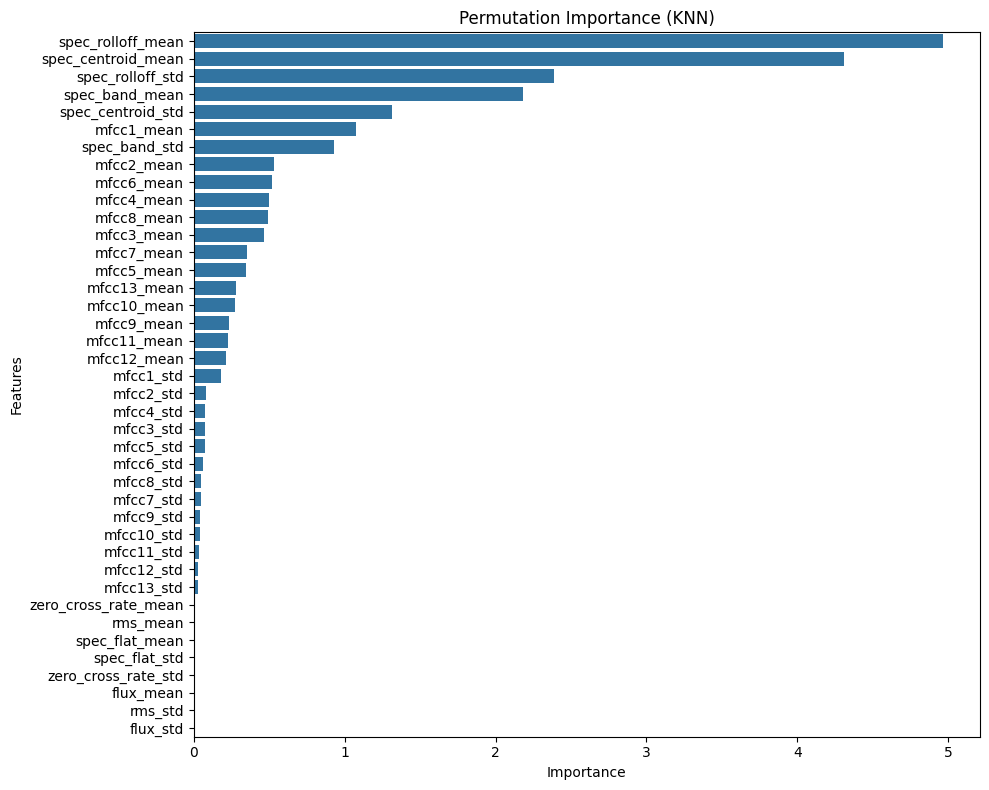

In [106]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

'''Principe :

On mesure la performance du modèle

On mélange une feature

On regarde combien la performance chute

Si elle chute beaucoup → feature importante.'''


# Permutation importance
result = permutation_importance(
    model_KNN,
    X,
    y,
    n_repeats=20,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

importances = result.importances_mean
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(10,8))

sns.barplot(
    x=importances[indices],
    y=calib.columns[:-1][indices]
)
print(train_KNN.score(X_test, y_test))

plt.title("Permutation Importance (KNN)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [107]:
# KNN Regressor
from sklearn.metrics import mean_absolute_error

# Prédictions
y_pred = train_KNN.predict(X_test)

# Tableau comparatif
comparaison = pd.DataFrame({
    "y_test": y_test.values,
    "y_pred": y_pred
})

# Ajouter l'erreur absolue
comparaison["erreur"] = abs(comparaison["y_test"] - comparaison["y_pred"])

print("tableaux de comparaison des données de test échnantillon")
print(comparaison)

# MAE
mae = round(mean_absolute_error(y_test, y_pred), 2)
print("MAE:", mae)

y_pred_real = model_KNN.predict(X_real) # on prend le modèle entrainé sur tout le dataset de calibration pour les prédictions réelles
# y_pred_real = train_KNN.predict(X_real)

# Tableau comparatif
comparaison = pd.DataFrame({
    "y_real": y_real.values,
    "y_pred": y_pred_real
})

# Ajouter l'erreur absolue
comparaison["erreur"] = abs(comparaison["y_real"] - comparaison["y_pred"])

print("tableaux de comparaison des données de mesures réelles")
print(comparaison)

# MAE
mae = round(mean_absolute_error(y_real, y_pred_real), 2)
print("MAE:", mae)

tableaux de comparaison des données de test échnantillon
    y_test     y_pred    erreur
0   18.867  13.551014  5.315986
1    0.000   0.022160  0.022160
2    9.050   7.195650  1.854350
3    7.518  13.769807  6.251807
4    4.990   5.160807  0.170807
5   15.870  16.580732  0.710732
6    4.340   4.495932  0.155932
7    6.230   6.441787  0.211787
8    0.020   0.006974  0.013026
9   16.051  16.064338  0.013338
10  25.000  18.460036  6.539964
11  15.354  12.760410  2.593590
12  12.886  18.034883  5.148883
13  20.876  18.731487  2.144513
14  23.255  21.498119  1.756881
15  15.105  11.706907  3.398093
16   9.990  12.163976  2.173976
17  20.533  17.868826  2.664174
MAE: 2.29
tableaux de comparaison des données de mesures réelles
   y_real     y_pred    erreur
0   8.930  17.103572  8.173572
1   9.290   6.314003  2.975997
2  10.090  17.292378  7.202378
3  11.049  10.771600  0.277400
4  11.120   6.290591  4.829409
5  11.760  12.693202  0.933202
6  12.500  12.256050  0.243950
7  18.650  13.591784  

# Random Forest

0.9059727832191735


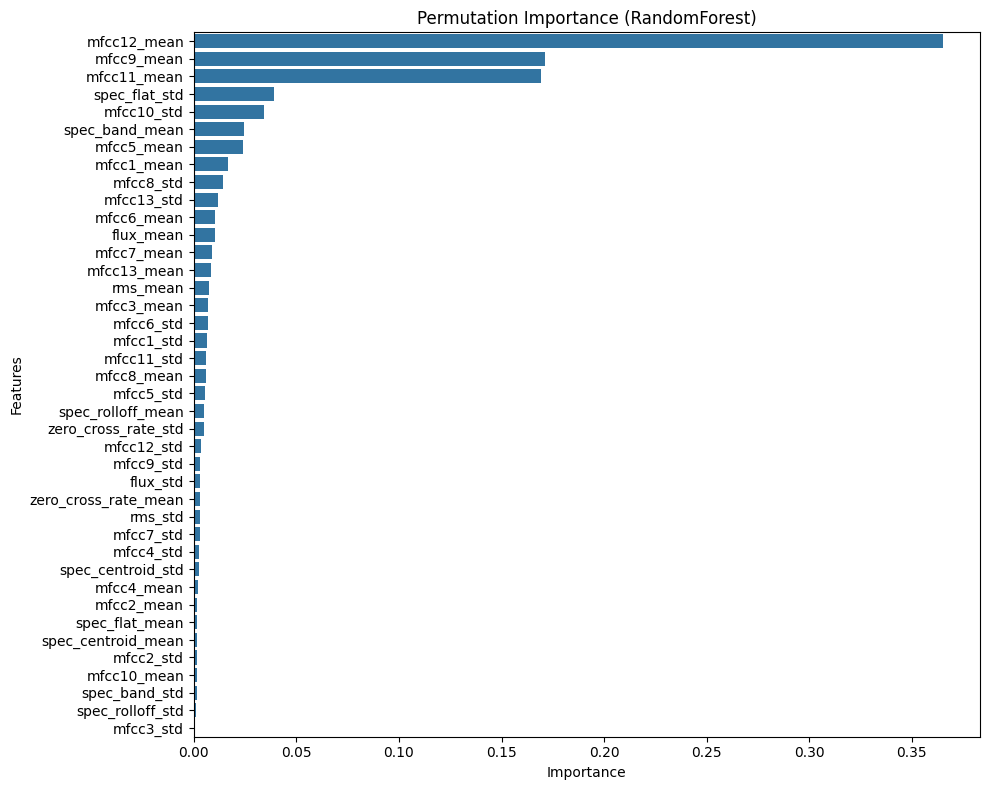

In [108]:
# Random Forest

model_rf, train_rf = load_rf_model()

importances = model_rf.feature_importances_

indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(10,8))

sns.barplot(
    x=importances[indices],
    y=calib.columns[:-1][indices]
)
print(train_rf.score(X_test, y_test))

plt.title("Permutation Importance (RandomForest)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [109]:
# Random forest regressor
from sklearn.metrics import mean_absolute_error

# Prédictions
y_pred = train_rf.predict(X_test)

# Tableau comparatif
comparaison = pd.DataFrame({
    "y_test": y_test.values,
    "y_pred": y_pred
})

# Ajouter l'erreur absolue
comparaison["erreur"] = abs(comparaison["y_test"] - comparaison["y_pred"])

print("tableaux de comparaison des données de test échnantillon")
print(comparaison)

# MAE
mae = round(mean_absolute_error(y_test, y_pred), 2)
print("MAE:", mae)

y_pred_real = model_rf.predict(X_real) # on prend le modèle entrainé sur tout le dataset de calibration pour les prédictions réelles
# y_pred_real = train_rf.predict(X_real)

# Tableau comparatif
comparaison = pd.DataFrame({
    "y_real": y_real.values,
    "y_pred": y_pred_real
})

# Ajouter l'erreur absolue
comparaison["erreur"] = abs(comparaison["y_real"] - comparaison["y_pred"])

print("tableaux de comparaison des données de mesures réelles")
print(comparaison)

# MAE
mae = round(mean_absolute_error(y_real, y_pred_real), 2)
print("MAE:", mae)

tableaux de comparaison des données de test échnantillon
    y_test    y_pred   erreur
0   18.867  17.83563  1.03137
1    0.000   0.01530  0.01530
2    9.050  13.81922  4.76922
3    7.518   7.24488  0.27312
4    4.990   5.06800  0.07800
5   15.870  13.40614  2.46386
6    4.340   4.44809  0.10809
7    6.230   6.76044  0.53044
8    0.020   0.45020  0.43020
9   16.051  15.66257  0.38843
10  25.000  17.98352  7.01648
11  15.354  14.43069  0.92331
12  12.886  12.07672  0.80928
13  20.876  20.54130  0.33470
14  23.255  22.20841  1.04659
15  15.105  15.24338  0.13838
16   9.990   8.28659  1.70341
17  20.533  17.55025  2.98275
MAE: 1.39


tableaux de comparaison des données de mesures réelles
   y_real    y_pred   erreur
0   8.930  10.41433  1.48433
1   9.290   8.01546  1.27454
2  10.090  15.45776  5.36776
3  11.049  12.08271  1.03371
4  11.120   8.05580  3.06420
5  11.760   9.19805  2.56195
6  12.500  13.99188  1.49188
7  18.650  19.05952  0.40952
8  21.270  19.39613  1.87387
MAE: 2.06


# Ridge Regression

R2 test : 0.8942199648260534


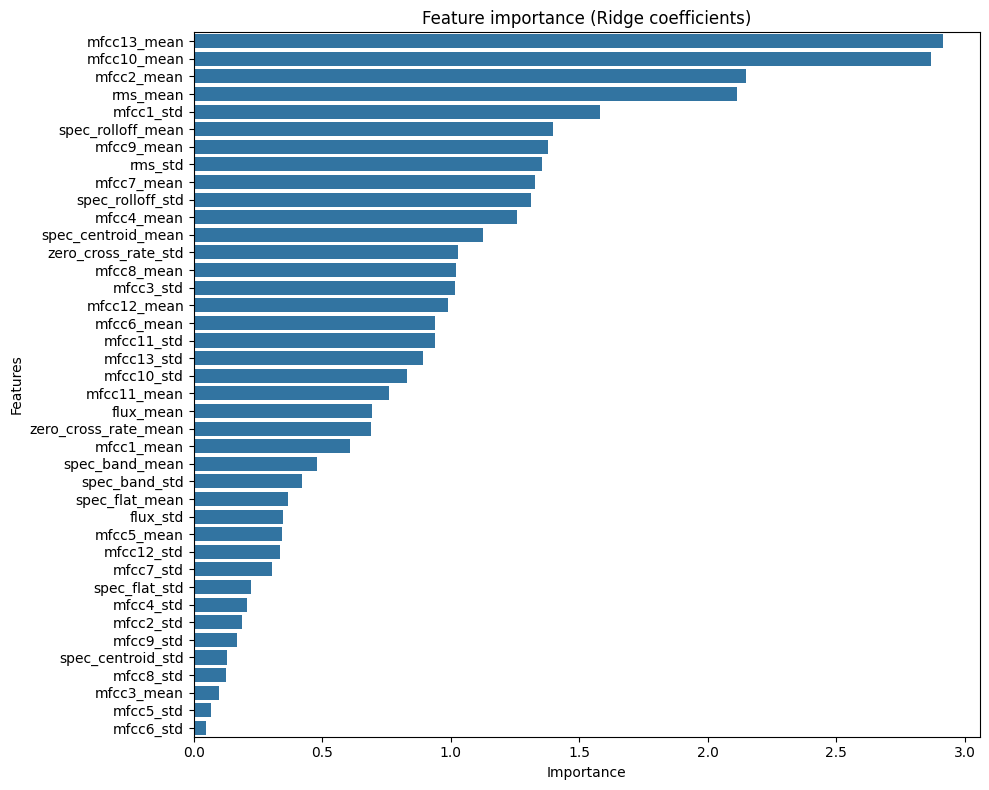

In [110]:

import matplotlib.pyplot as plt
import seaborn as sns


# Importance = valeur absolue des coefficients
importances = np.abs(model_ridge.coef_)

# Tri
indices = np.argsort(importances)[::-1]

# Score test
score = train_ridge.score(X_test_scaled, y_test)
print("R2 test :", score)

# Plot
plt.figure(figsize=(10,8))
sns.barplot(
    x=importances[indices],
    y=calib.columns[:-1][indices]
)

plt.title("Feature importance (Ridge coefficients)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


In [111]:
# Ridge
from sklearn.metrics import mean_absolute_error

# Prédictions
y_pred = train_ridge.predict(X_test_scaled)

# Tableau comparatif
comparaison = pd.DataFrame({
    "y_test": y_test.values,
    "y_pred": y_pred
})

# Ajouter l'erreur absolue
comparaison["erreur"] = abs(comparaison["y_test"] - comparaison["y_pred"])

print("tableaux de comparaison des données de test échnantillon")
print(comparaison)

# MAE
mae = round(mean_absolute_error(y_test, y_pred), 2)
print("MAE:", mae)

y_pred_real = model_ridge.predict(X_test_real_scaled) # on prend le modèle entrainé sur tout le dataset de calibration pour les prédictions réelles
# y_pred_real = train_rf.predict(X_real)

# Tableau comparatif
comparaison = pd.DataFrame({
    "y_real": y_real.values,
    "y_pred": y_pred_real
})

# Ajouter l'erreur absolue
comparaison["erreur"] = abs(comparaison["y_real"] - comparaison["y_pred"])

print("tableaux de comparaison des données de mesures réelles")
print(comparaison)

# MAE
mae = round(mean_absolute_error(y_real, y_pred_real), 2)
print("MAE:", mae)

tableaux de comparaison des données de test échnantillon
    y_test     y_pred    erreur
0   18.867  17.520449  1.346551
1    0.000  -0.114673  0.114673
2    9.050  12.280185  3.230185
3    7.518   5.978434  1.539566
4    4.990   4.810572  0.179428
5   15.870  16.214265  0.344265
6    4.340   5.409009  1.069009
7    6.230   8.486934  2.256934
8    0.020  -0.118792  0.138792
9   16.051  15.970201  0.080799
10  25.000  17.311402  7.688598
11  15.354  14.582714  0.771286
12  12.886  12.171124  0.714876
13  20.876  21.336466  0.460466
14  23.255  20.460724  2.794276
15  15.105  16.511033  1.406033
16   9.990   9.307101  0.682899
17  20.533  16.735750  3.797250
MAE: 1.59
tableaux de comparaison des données de mesures réelles
   y_real     y_pred     erreur
0   8.930  11.492761   2.562761
1   9.290  -0.216475   9.506475
2  10.090  13.784626   3.694626
3  11.049  10.581688   0.467312
4  11.120  -0.489664  11.609664
5  11.760   9.596175   2.163825
6  12.500  14.883613   2.383613
7  18.650  17.

# Lasso Regression

R2 test : 0.9614118104191574


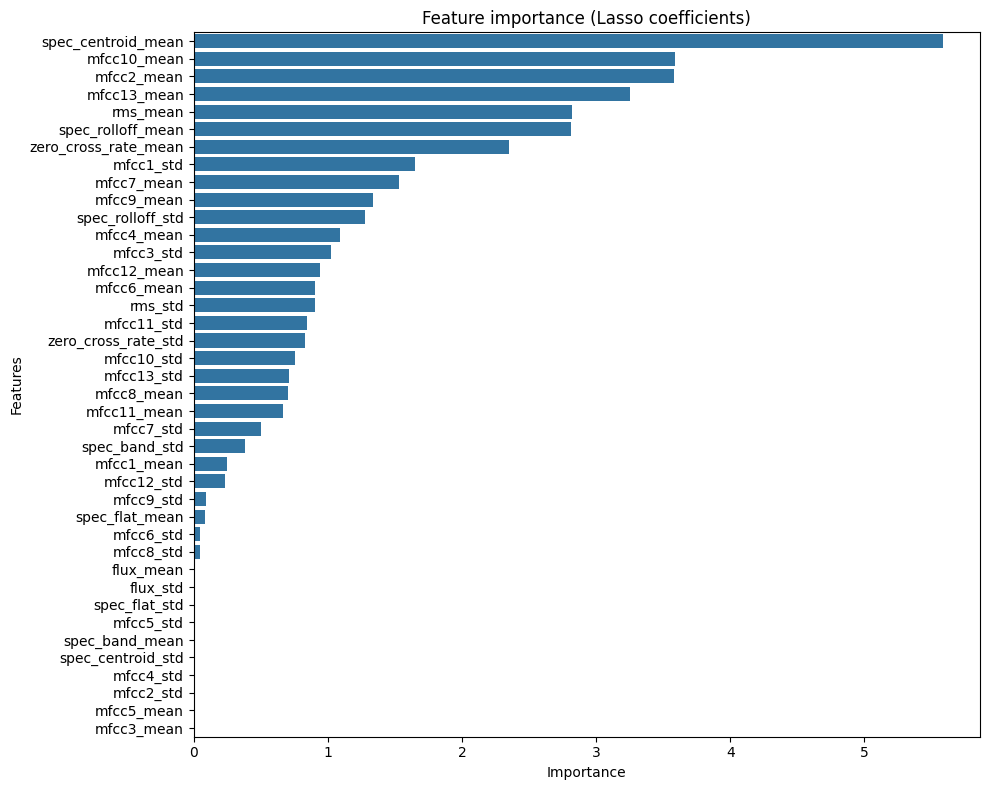

In [112]:


import matplotlib.pyplot as plt
import seaborn as sns



# Importance = valeur absolue des coefficients
importances = np.abs(model_lasso.coef_)

# Tri
indices = np.argsort(importances)[::-1]

# Score test
score = model_lasso.score(X_test_scaled, y_test)
print("R2 test :", score)

# Plot
plt.figure(figsize=(10,8))
sns.barplot(
    x=importances[indices],
    y=calib.columns[:-1][indices]
)

plt.title("Feature importance (Lasso coefficients)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

# Features sélectionnées par Lasso
selected_features = calib.columns[:-1][model_lasso.coef_ != 0]
# print("Features retenues par Lasso :")
# print(selected_features)


In [113]:
# Ridge
from sklearn.metrics import mean_absolute_error

# Prédictions
y_pred = train_lasso.predict(X_test_scaled)

# Tableau comparatif
comparaison = pd.DataFrame({
    "y_test": y_test.values,
    "y_pred": y_pred
})

# Ajouter l'erreur absolue
comparaison["erreur"] = abs(comparaison["y_test"] - comparaison["y_pred"])

print("tableaux de comparaison des données de test échnantillon")
print(comparaison)

# MAE
mae = round(mean_absolute_error(y_test, y_pred), 2)
print("MAE:", mae)

y_pred_real = model_lasso.predict(X_test_real_scaled) # on prend le modèle entrainé sur tout le dataset de calibration pour les prédictions réelles
# y_pred_real = train_rf.predict(X_real)

# Tableau comparatif
comparaison = pd.DataFrame({
    "y_real": y_real.values,
    "y_pred": y_pred_real
})

# Ajouter l'erreur absolue
comparaison["erreur"] = abs(comparaison["y_real"] - comparaison["y_pred"])

print("tableaux de comparaison des données de mesures réelles")
print(comparaison)

# MAE
mae = round(mean_absolute_error(y_real, y_pred_real), 2)
print("MAE:", mae)

tableaux de comparaison des données de test échnantillon
    y_test     y_pred    erreur
0   18.867  17.747331  1.119669
1    0.000  -0.146843  0.146843
2    9.050  11.755256  2.705256
3    7.518   6.156465  1.361535
4    4.990   4.354411  0.635589
5   15.870  16.361972  0.491972
6    4.340   5.444709  1.104709
7    6.230   8.452628  2.222628
8    0.020  -0.121381  0.141381
9   16.051  15.909998  0.141002
10  25.000  17.764298  7.235702
11  15.354  14.580081  0.773919
12  12.886  11.855798  1.030202
13  20.876  21.289228  0.413228
14  23.255  20.833351  2.421649
15  15.105  16.218150  1.113150
16   9.990   8.674352  1.315648
17  20.533  16.830106  3.702894
MAE: 1.56
tableaux de comparaison des données de mesures réelles
   y_real     y_pred     erreur
0   8.930  10.941753   2.011753
1   9.290  -0.339826   9.629826
2  10.090  13.546534   3.456534
3  11.049  10.458677   0.590323
4  11.120  -0.617486  11.737486
5  11.760   9.627852   2.132148
6  12.500  14.682459   2.182459
7  18.650  17.

Rappel : qu’est-ce que mfcc7_mean ?

Les MFCC (Mel-Frequency Cepstral Coefficients) décrivent :

la forme du spectre

la structure fréquentielle globale

le “timbre” du signal

mfcc7_mean = moyenne temporelle du 7ᵉ coefficient.

👉 Donc c’est une information spectrale compressée.

Si le débit influence :

    la pression

    la turbulence

    le bruit généré

    la répartition énergétique dans le spectre

Alors il est plausible qu’un MFCC soit corrélé au débit.

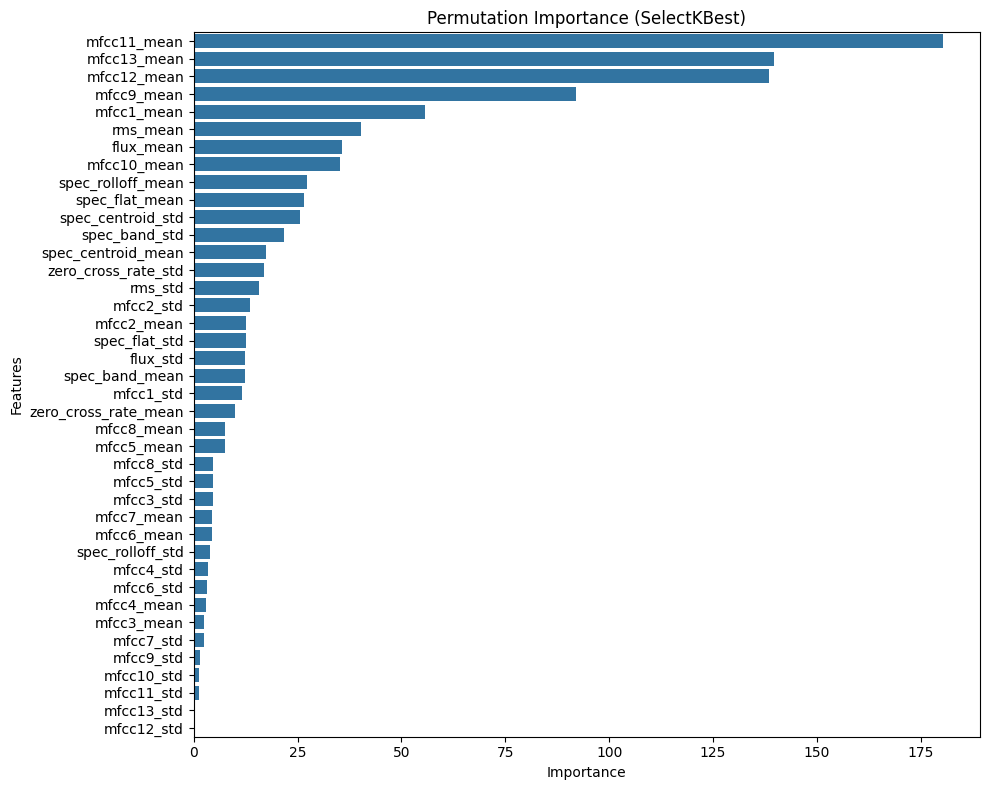

In [114]:
from sklearn.feature_selection import SelectKBest, f_regression

# mesure corrélation linéaire uniquement!!

selector = SelectKBest(score_func=f_regression, k="all")
selector.fit(X, y)


importances = selector.scores_
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(10,8))

sns.barplot(
    x=importances[indices],
    y=calib.columns[:-1][indices]
)

plt.title("Permutation Importance (SelectKBest)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

## Estimate Flow for a Segment

In [115]:
def estimate_flow(feat, model):
    """
    feat : vecteur features 1D (35 features par ex.)
    model : modèle KNeighborsRegressor déjà entraîné
    """
    
    feat = np.array(feat).reshape(1, -1)  # nécessaire pour sklearn
    prediction = model.predict(feat)

    return prediction[0]


## Analyze a Real Recording

In [116]:
def analyze_recording(file_path, nn, y_calib):
    y, sr = librosa.load(file_path, sr=32000)
    segments, frame_len = segment_audio(y, sr)

    results = []

    for i, (s, e) in enumerate(segments):
        seg = y[s*frame_len:e*frame_len]
        feat = extract_features(seg, sr)
        debit = estimate_flow(feat, nn, y_calib)
        duration = (e - s) * 0.2
        results.append({"phase": i+1, "debit": debit, "duree": duration})

    return results


## Plot Uroflow Curve

In [117]:
def plot_uroflow(results):
    times = []
    flows = []
    t = 0

    for r in results:
        times.append(t)
        flows.append(r['debit'])
        t += r['duree']

    plt.step(times, flows)
    plt.xlabel('Time (s)')
    plt.ylabel('Flow (ml/s)')
    plt.title('Estimated Uroflow Curve')
    plt.show()
